In [1]:
%load_ext autoreload

In [2]:
import sys, os

dir = os.path.abspath('..')
sys.path.append(os.path.join(dir))

In [3]:
from synth_utils import Demo

language_1 = 'You want to grab the box, move towards the human and if they are left handed you want to leave the box by their left side, otherwise drop the box by their right side. Finally go back to your original spot.'

demos = [
    Demo(id='demo_1', scene=None, language=language_1, video=None)
]

In [4]:
from factory_api.api import api
from infer_utils import Inference
acts = Inference.act_from(demos, api)

100%|██████████| 1/1 [00:13<00:00, 13.61s/it]

Inference done.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


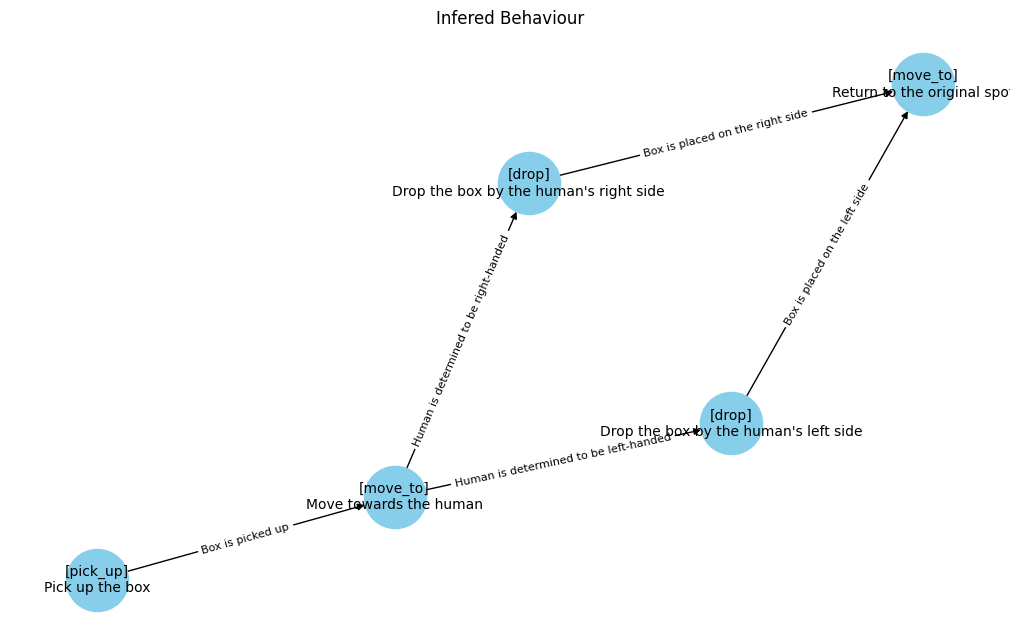

In [11]:
for a in acts:
    a.show()

In [ ]:
import json

OUT_DIR = 'exports'

os.makedirs(OUT_DIR, exist_ok=True)
for idx, a in enumerate(acts):

    id = f'act_{idx + 1}'
    data = a.to_dict(id=id, expanded=False)

    with open(f'{OUT_DIR}/{id}.json', 'w') as f:
        json.dump(data, f, indent=4)

In [ ]:
# TODO: Automate act editing

In [ ]:
# NOTE: Import final act
act = acts[0]

In [ ]:
%load_ext autoreload
%autoreload 2

from synth_utils import Synth

synth = Synth(act, demos, api)
synth.run()

In [ ]:
%load_ext autoreload
%autoreload 2

program = synth.to_dict()
print(json.dumps(program, indent=4))